<a href="https://colab.research.google.com/github/arnaldojr/cognitivecomputing/blob/master/material/aulas/PDI/lab02/atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objetivos da aula:**

*   Filtro negativo de imagem
*   Recorte da imagem
*   Seguimentação por pixel

In [1]:
%matplotlib inline
# Importando a biblioteca OpenCV
import cv2 

#import a biblioteca Numpy
import numpy as np

from matplotlib import pyplot as plt


print ("OpenCV Versão : %s " % cv2.__version__)

OpenCV Versão : 4.13.0 


In [5]:
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/cogumelo.png" /content
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/droneinvertido.jpg" /content
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/drone.jpg" /content
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/droneinvertido.jpg" /content
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/goku.jpg" /content
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/gokuinvertido.jpg" /content
!wget "https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/PDI/lab02/cogumelo.png" /content

--2023-02-10 19:36:13--  https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/lab02/cogumelo.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48478 (47K) [image/png]
Saving to: ‘cogumelo.png.2’


cogumelo.png.2        0%[                    ]       0  --.-KB/s               
cogumelo.png.2      100%[===================>]  47.34K  --.-KB/s    in 0.01s   

2023-02-10 19:36:13 (4.58 MB/s) - ‘cogumelo.png.2’ saved [48478/48478]

/content: Scheme missing.
FINISHED --2023-02-10 19:36:13--
Total wall clock time: 0.06s
Downloaded: 1 files, 47K in 0.01s (4.58 MB/s)
--2023-02-10 19:36:13--  https://raw.githubusercontent.com/arnaldojr/cognitivecomputing/master/material/aulas/lab02/droneinvertido.jpg
Resolving raw.githubusercontent.com

## Filtro negativo (Inverte imagem)

Para aplicar um filtro negativo precisamos inverter os seus valores, ou seja, em uma imagem binária realizamos a troca de 0 pra 1 e de 1 para 0 para cada pixel da imagem. 

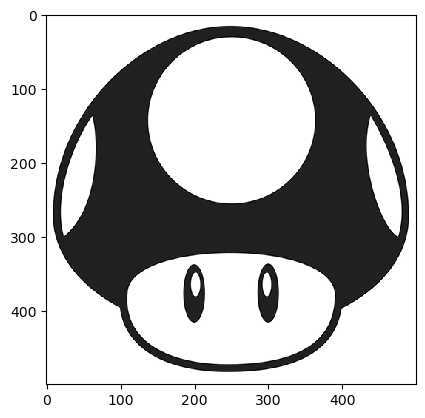

In [3]:
import cv2  # Importa a biblioteca OpenCV, usada para operações de processamento de imagens.
 
imagem = cv2.imread("cogumelo.png")  # Lê a imagem "cogumelo.png" no formato BGR (Blue, Green, Red).
 
image = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)  # Converte a imagem de BGR (cor) para escala de cinza (grayscale).
 
plt.imshow(image, interpolation="none", cmap="gray")  # Exibe a imagem convertida para escala de cinza com Matplotlib.
# A opção "none" na interpolação impede que a imagem seja suavizada ou esticada.
# O cmap="gray" garante que a imagem seja exibida em tons de cinza, pois a imagem agora é grayscale.
 
plt.show()  # Exibe a imagem na tela. Esta linha é responsável por mostrar a imagem gerada no ambiente interativo.

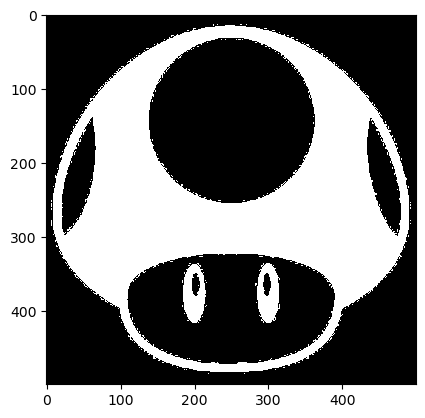

In [4]:
import cv2  # Importa a biblioteca OpenCV, que será usada para manipulação de imagens.
imagem = cv2.imread("cogumelo.png")  # Lê a imagem "cogumelo.png" no formato BGR (Blue, Green, Red).
image = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)  # Converte a imagem BGR para escala de cinza (grayscale).

# Loop para percorrer todos os pixels da imagem.
for y in range(0, image.shape[0]):  # O loop percorre todas as linhas da imagem (altura).
  for x in range(0, image.shape[1]):  # O loop percorre todas as colunas da imagem (largura).
    
    ##### aqui eu inverto o valor do pixel
    if image[y, x] == 255:  # Se o pixel for branco (valor máximo de intensidade de cinza, 255).
      image[y, x] = 0  # Então, o pixel se torna preto (valor mínimo de intensidade de cinza, 0).
    else:  # Se o pixel não for branco (provavelmente preto ou algum tom de cinza).
      image[y, x] = 255  # O pixel se torna branco (valor 255).

# Exibe a imagem resultante, que teve seus pixels invertidos.
plt.imshow(image, interpolation="none", cmap="gray")  # Exibe a imagem em tons de cinza, sem suavização.
plt.show()  # Exibe a imagem na tela.

## Desafio 1

Faça uma implementação que inverte as cores de uma imagem em escala de cinza, com valores que vão de 0 ate 255. 
dica: a forma explicita de fazer uma inversãão é: a = 255 - a

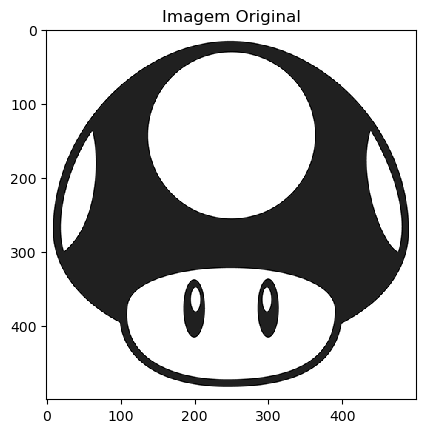

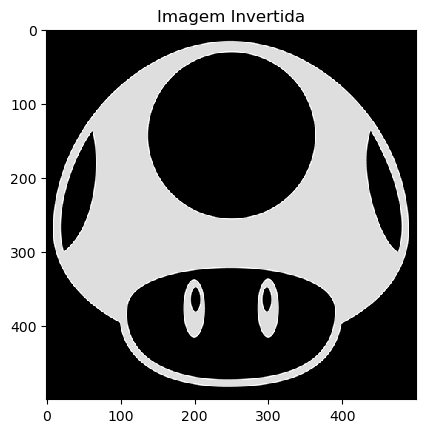

In [5]:

import cv2  # Importa a biblioteca OpenCV para manipulação de imagens.
import numpy as np  # Importa a biblioteca Numpy para manipulação de arrays/matrizes.

# Carregando a imagem em escala de cinza
imagem = cv2.imread("cogumelo.png", cv2.IMREAD_GRAYSCALE)  # Lê a imagem diretamente em escala de cinza (0 a 255).

# Exibe a imagem original antes da inversão
plt.imshow(imagem, cmap='gray', interpolation='none')  # Exibe a imagem original
plt.title("Imagem Original")
plt.show()

# Invertendo as cores de todos os pixels da imagem
for y in range(imagem.shape[0]):  # Loop para percorrer todas as linhas da imagem (altura)
    for x in range(imagem.shape[1]):  # Loop para percorrer todas as colunas da imagem (largura)
        imagem[y, x] = 255 - imagem[y, x]  # Inversão do valor do pixel (255 - valor do pixel)

# Exibe a imagem após a inversão
plt.imshow(imagem, cmap='gray', interpolation='none')  # Exibe a imagem com as cores invertidas
plt.title("Imagem Invertida")
plt.show()


## Desafio 2 

Faça o mesmo par uma imagem colorida, realize a inversão de cores dos canais R, G e B. 

o resultado deve ser parecido com a imagem abaixo: 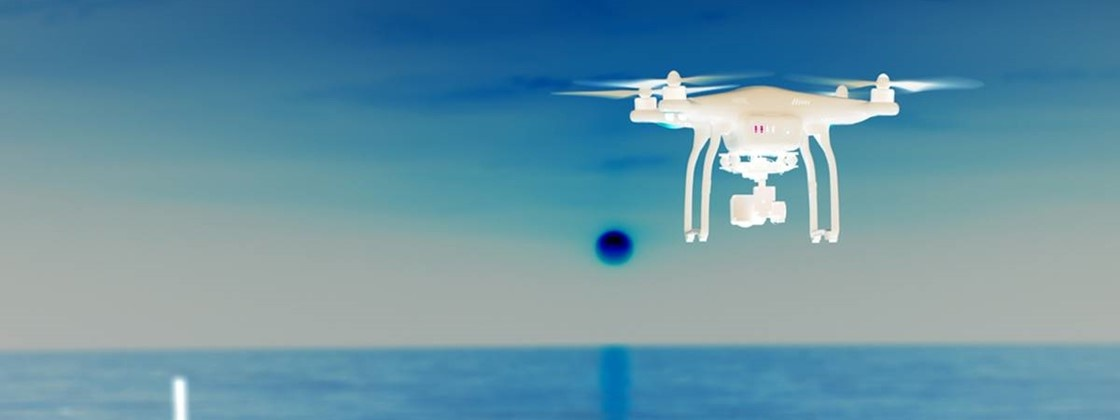


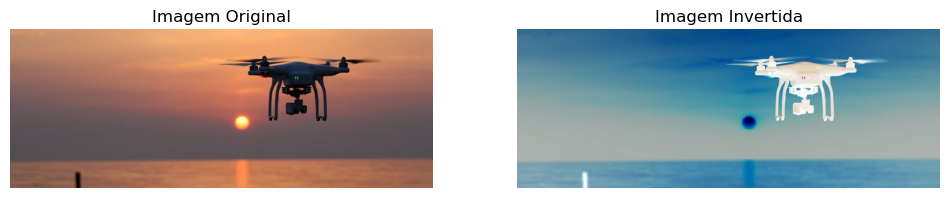

In [6]:
import cv2  # Importa a biblioteca OpenCV, usada para ler e manipular imagens
import numpy as np  # Importa a biblioteca Numpy para manipulação de matrizes (imagens)
import matplotlib.pyplot as plt  # Importa o matplotlib para exibição de imagens no Jupyter

# Carrega a imagem em formato BGR (padrão do OpenCV)
imagem = cv2.imread("drone.jpg")  

# Converte a imagem de BGR para RGB para exibição correta no matplotlib
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)  

# Inverte as cores dos canais R, G e B
# A operação 255 - valor do pixel faz a inversão, pois 255 é o valor máximo em uma imagem de 8 bits
imagem_rgb_invertida = 255 - imagem_rgb  

# Exibe as imagens usando matplotlib
plt.figure(figsize=(12, 6))  # Define o tamanho da figura (12x6 polegadas)

# Exibe a imagem original no primeiro subplot (lado esquerdo)
plt.subplot(1, 2, 1)  
plt.imshow(imagem_rgb)  # Exibe a imagem em RGB
plt.title("Imagem Original")  # Título do lado esquerdo
plt.axis('off')  # Remove os eixos (sem marcação de valores ao redor da imagem)

# Exibe a imagem invertida no segundo subplot (lado direito)
plt.subplot(1, 2, 2)  
plt.imshow(imagem_rgb_invertida)  # Exibe a imagem com as cores invertidas
plt.title("Imagem Invertida")  # Título do lado direito
plt.axis('off')  # Remove os eixos

plt.show()  # Exibe a figura com as duas imagens lado a lado

## Recorte da imagem (crop)

O recorte de uma parte da imagem, ou crop, consiste em extrair da imagem uma região de interresse (ROI).

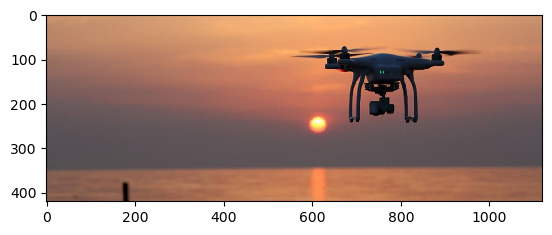

In [7]:
import cv2  # Importa a biblioteca OpenCV, usada para manipulação de imagens.
imagem = cv2.imread("drone.jpg")  # Lê a imagem "drone.jpg" no formato BGR (padrão do OpenCV).

image = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)  # Converte a imagem de BGR para RGB (para exibição correta no Matplotlib).

plt.imshow(image, interpolation="none")  # Exibe a imagem utilizando Matplotlib, sem interpolação (sem suavizar a imagem).

plt.show()  # Exibe a imagem na tela.

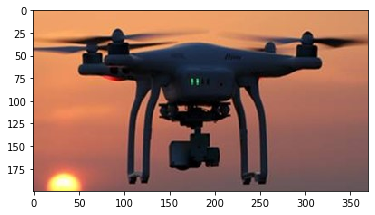

In [11]:
image2 = image.copy()  # Cria uma cópia da imagem original. A variável "image2" agora contém a mesma imagem que "image", mas de forma independente.

#crop_img = img[y:y+h, x:x+w]  # Comentado: Este código geralmente é usado para cortar uma parte de uma imagem, especificando a área de corte (x, y) como o canto superior esquerdo, e (w, h) como a largura e altura do retângulo a ser cortado.

# A linha abaixo corta a imagem "image" para um novo retângulo, onde:
# A linha 50 até a linha 250 (vertical) e
# Da coluna 580 até a coluna 950 (horizontal).
# Isso cria uma nova imagem com uma "parte" da imagem original.
image2 = image[50:250, 580:950]  # "Corta" a imagem entre as coordenadas especificadas

# Exibe a parte cortada da imagem em tons de cinza
plt.imshow(image2, interpolation="none", cmap="gray")  # Exibe a imagem cortada usando o Matplotlib com mapa de cores 'gray' (escala de cinza)
plt.show()  # Exibe a imagem

## Desafio3

Ajude o nosso sayajin!! 

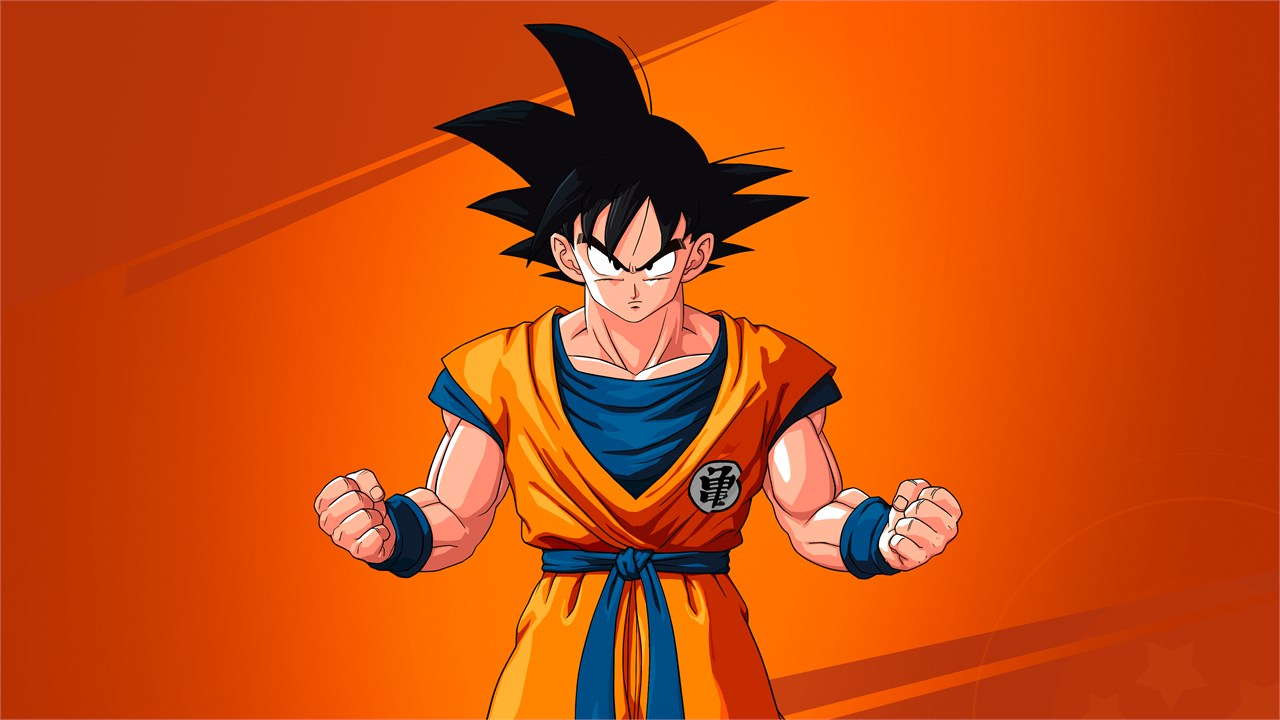

A imagem foi dividida em 4 quadrantes aleatorios e precisamos organizar essa bagunça. Faça a reconstrução da imagem nas posições corretas. 

Dica: Crie uma copia da imagem original (img2 = img.copy()), faça um crop da imagem 4 partes (crop1, crop2, crop3, crop4), junte as partes cortadas na ordem correta na img2. no final Salve a imagem (cv2.imwrite())

altura: 720 largura: 1280


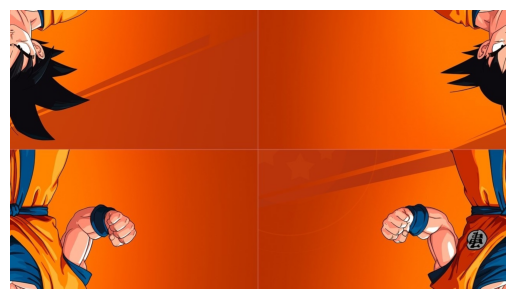

In [ ]:
import cv2  # Importa a biblioteca OpenCV, usada para manipulação de imagens.
imagem = cv2.imread("gokuinvertido.jpg")  # Lê a imagem "gokuinvertido.jpg" no formato BGR (padrão do OpenCV).
image = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)  # Converte a imagem de BGR (usado pelo OpenCV) para RGB (padrão para exibição no Matplotlib).

# Obtém as dimensões da imagem:
altura = image.shape[0]  # A altura da imagem (número de linhas, ou pixels verticais).
largura = image.shape[1]  # A largura da imagem (número de colunas, ou pixels horizontais).

# Exibe a altura e a largura da imagem no console.
print("altura: {} largura: {}".format(altura, largura))

# Exibe a imagem utilizando o Matplotlib.
# A opção "interpolation='none'" faz com que os pixels não sejam suavizados e a imagem seja exibida como está.
plt.imshow(image, interpolation="none")

# Exibe a imagem na tela.
plt.show()

# Comentado: Aqui está o código para salvar a imagem com as cores invertidas.
# A função cv2.imwrite() salva a imagem em um arquivo. 
# A imagem precisa ser convertida de RGB para BGR antes de ser salva, pois o OpenCV usa o formato BGR ao salvar imagens.
# cv2.imwrite("gokunormal.jpg", cv2.cvtColor(image2, cv2.COLOR_RGB2BGR))

altura 720, altura metade 360 do tipo <class 'int'>
largura 1280, largura metade 640 do tipo <class 'int'>


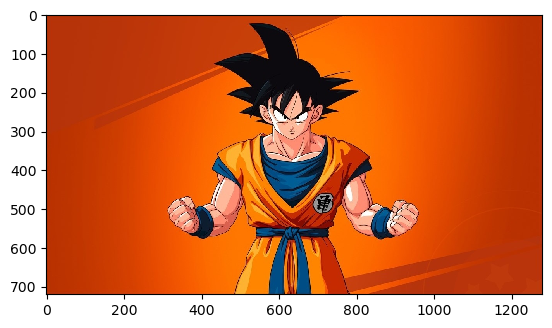

In [8]:
import cv2  # Importa a biblioteca OpenCV para manipulação de imagens

# Carrega a imagem "gokuinvertido.jpg" no formato BGR (padrão do OpenCV)
imagem = cv2.imread("gokuinvertido.jpg")

# Converte a imagem de BGR (formato OpenCV) para RGB (para exibição correta com Matplotlib)
image = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Obtém a altura (número de linhas) e largura (número de colunas) da imagem
altura = image.shape[0]  # Altura da imagem (linhas)
largura = image.shape[1]  # Largura da imagem (colunas)

# Calcula a altura e largura "metade" para cortar a imagem em quatro partes
altura_meio = int(altura / 2)  # Divisão inteira da altura
largura_meio = largura // 2    # Divisão inteira da largura (sem precisar de float)

# Imprime a altura original, a metade da altura e o tipo de dado da variável `altura_meio`
print(f"altura {altura}, altura metade {altura_meio} do tipo {type(altura_meio)}")

# Imprime a largura original, a metade da largura e o tipo de dado da variável `largura_meio`
print(f"largura {largura}, largura metade {largura_meio} do tipo {type(largura_meio)}")

# Cria uma cópia da imagem original
image2 = image.copy()

# Divide a imagem em 4 partes (quatro quadrantes)
# Cada parte é um recorte (crop) da imagem original
crop1 = image2[0:altura_meio, 0:largura_meio]  # Parte superior esquerda
crop2 = image2[0:altura_meio, largura_meio:largura]  # Parte superior direita
crop3 = image2[altura_meio:altura, 0:largura_meio]  # Parte inferior esquerda
crop4 = image2[altura_meio:altura, largura_meio:largura]  # Parte inferior direita

# Reorganiza as partes (quadrantes) dentro da imagem original
# Fazendo uma troca de quadrantes, cada parte da imagem original será movida para uma nova posição
image[altura_meio:altura, largura_meio:largura] = crop1  # Troca a parte inferior direita com a parte superior esquerda
image[altura_meio:altura, 0:largura_meio] = crop2  # Troca a parte inferior esquerda com a parte superior direita
image[0:altura_meio, largura_meio:largura] = crop3  # Troca a parte superior direita com a parte inferior esquerda
image[0:altura_meio, 0:largura_meio] = crop4  # Troca a parte superior esquerda com a parte inferior direita

# Exibe a imagem resultante após os cortes e rearranjos
plt.imshow(image, interpolation="none")  # Exibe a imagem com os quadrantes reorganizados
plt.show()  # Exibe a imagem na tela

# Para salvar a imagem resultante (comentado)
# cv2.imwrite("gokunormal.jpg", cv2.cvtColor(image2, cv2.COLOR_RGB2BGR))  # Salva a imagem final em formato BGR, pois o OpenCV usa BGR para salvar

## Seguimentação de imagens

Agora que sabemos como manipular pixel e como alterar seu valor e sua posição. Podemos fazer atividades mais complexas como conseguir reaalizar a seguimentação de algum objeto ou item da imagem (video), Como na imagem abaixo.

## Desafio 4 

De forma intuitiva realize algumas mudanças no código e veja o efeito que causa na imagem. Este exercio é apenas um aperitivo de algumas tecnicas que vamos estudar na proxima aula. 

(420, 1120, 3)


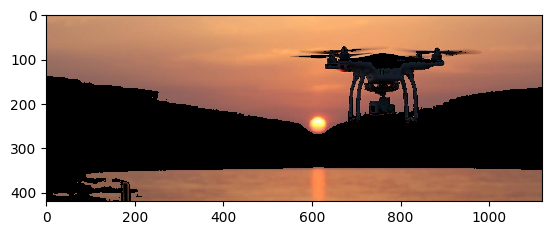

In [ ]:
# Entenda o código e faça as alterações que achar necessárias
import cv2  # Importa a biblioteca OpenCV para manipulação de imagens.

# Lê a imagem "drone.jpg" no formato BGR (padrão do OpenCV)
imagem = cv2.imread("drone.jpg")

# Converte a imagem de BGR (formato do OpenCV) para RGB (para exibição correta no Matplotlib)
image = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Imprime as dimensões da imagem (altura, largura e número de canais de cor)
print(image.shape)  # A saída será algo como (altura, largura, 3) para uma imagem RGB

# Loop que percorre cada pixel da imagem
for y in range(0, image.shape[0]):  # Percorre todas as linhas da imagem (altura)
  for x in range(0, image.shape[1]):  # Percorre todas as colunas da imagem (largura)
    
    # Verifica se o valor no canal vermelho (R) é maior que 50 e o canal azul (B) é menor que 140
    if image[y, x, 2] > 50 and image[y, x, 0] < 140:  
      # Se a condição for atendida, altera o pixel para preto (0,0,0) no formato RGB
      image[y, x] = (0, 0, 0)  # Substitui o pixel pela cor preta (RGB = 0,0,0)

# Exibe a imagem com os pixels alterados, usando o Matplotlib (sem suavização de pixels)
plt.imshow(image, interpolation="none")  # Exibe a imagem com a interpolação desativada (sem suavizar os pixels)
plt.show()  # Exibe a imagem na tela

## Desafio 5

Vamos tentar fazer o contrario, vamos tentar filtar o fundo da imagem sem o drone

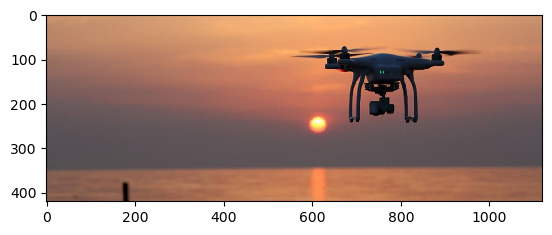

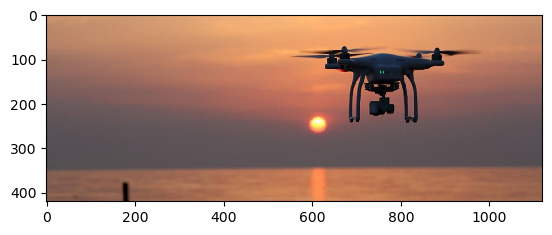

In [12]:
import cv2  # Importa a biblioteca OpenCV para manipulação de imagens.
import numpy as np  # Importa a biblioteca Numpy para manipulação de matrizes (imagens).
import matplotlib.pyplot as plt  # Importa o Matplotlib para exibição de imagens.

# Lê a imagem "drone.jpg" no formato BGR (padrão do OpenCV).
imagem = cv2.imread("drone.jpg")

# Converte a imagem de BGR (formato OpenCV) para RGB (para exibição correta no Matplotlib).
image = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Exibe a imagem original para referência.
plt.imshow(image, interpolation="none")
plt.show()

# Aplicando uma máscara para filtrar o fundo.
# O fundo tem geralmente um tom mais claro, como o céu e a água.
# Definindo limites para o filtro de cor (filtro simples baseado em cor).
lower_blue = np.array([0, 0, 150])  # Limite inferior para as cores do fundo (cor mais clara).
upper_blue = np.array([150, 150, 255])  # Limite superior para as cores do fundo.

# Criação da máscara para identificar o fundo (áreas mais claras).
mask = cv2.inRange(image, lower_blue, upper_blue)

# Inversão da máscara (para selecionar as áreas sem o fundo, onde o drone está).
mask_inv = cv2.bitwise_not(mask)

# Filtrando a imagem para remover o fundo (onde a máscara for 0, o fundo será removido).
background = cv2.bitwise_and(image, image, mask=mask_inv)

# Exibe a imagem sem o fundo.
plt.imshow(background, interpolation="none")
plt.show()